# The Nile's Secret: A Bayesian Detective Story

> *"For thousands of years, the annual flooding of the Nile was the single most important event in the lives of millions. When did that ancient rhythm break — and can we prove it with data?"*

This notebook is a detective story. The crime scene is the Nile River. The evidence is a century of annual flow measurements. Our tools are Bayesian inference and information-theoretic diagnostics. And the suspect is a dam.

Along the way, we will meet some remarkable characters — a Presbyterian minister who never published his most important idea, a French mathematician who applied it to the heavens, a Cambridge geophysicist who kept the flame alive for fifty years, and a 21st-century astrophysicist who built the computational tool we'll use today.

But first: the river.

---

## The World's Longest Data Story

The Nile is not just a river. For five thousand years, it was the beating heart of one of humanity's greatest civilizations. Every summer, monsoon rains in the Ethiopian highlands would swell the Blue Nile, sending a wall of nutrient-rich water downstream through Egypt. The annual flood — the *inundation* — deposited fertile silt across the floodplain, enabling agriculture in an otherwise barren desert.

The Egyptians understood the stakes. A flood too low meant famine. A flood too high meant destruction. And so they built **Nilometers** — stone columns, wells, and staircases marked with measurement scales — to record the height of each year's flood. The oldest known Nilometer, on the island of Elephantine near Aswan, dates to around 3000 BC. This is, quite literally, one of the oldest continuous data collection efforts in human history.

<!-- Portrait: A Nilometer on Elephantine Island — five millennia of data-driven governance -->

The flood level determined the tax rate. High flood, good harvest, higher taxes. Low flood, poor harvest, lower taxes. *Data-driven policy*, implemented by pharaohs three thousand years before the term was invented.

Then, in the late 19th century, something changed.

**Sir William Willcocks** (1852–1932), a British civil engineer who had built irrigation works across India, was dispatched to Egypt with an ambitious mission: tame the Nile. In 1898, construction began on the **Aswan Low Dam** — a massive granite barrier across the river at the First Cataract. When completed in 1902, it was the largest masonry dam in the world.

The dam transformed Egypt's agriculture from flood-dependent to irrigation-based. But it also changed the river's natural flow pattern — permanently.

**Our question**: Can we detect this change *purely from the flow data*, without knowing anything about the dam? And can our information-theoretic tools tell us *how confident* we should be in the answer?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

import arviz as az
import emcee

from divergence import (
    chain_divergence,
    chain_two_sample_test,
    information_gain,
    mixing_diagnostic,
    bayesian_surprise,
    prior_sensitivity,
    uncertainty_decomposition,
)

plt.rcParams.update({
    'figure.figsize': (10, 4.5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})

np.random.seed(42)

## The Evidence

Our dataset is the **annual flow of the Nile at Aswan**, measured from 1871 to 1970 — one hundred years of careful hydrological records, in units of $10^8$ cubic meters. This dataset has become a classic in Bayesian statistics, used by Cobb (1978) and countless textbooks since.

In [2]:
# Annual flow of the Nile at Aswan, 1871-1970, in 10^8 m^3
nile_flow = np.array([
    1120, 1160, 963, 1210, 1160, 1160, 813, 1230, 1370, 1140,
    995, 935, 1110, 994, 1020, 960, 1180, 799, 958, 1140,
    1100, 1210, 1150, 1250, 1260, 1220, 1030, 1100, 774, 840,
    874, 694, 940, 833, 701, 916, 692, 1020, 1050, 969,
    831, 726, 456, 824, 702, 1120, 1100, 832, 764, 821,
    768, 845, 864, 862, 698, 845, 744, 796, 1040, 759,
    781, 865, 845, 944, 984, 897, 822, 1010, 771, 676,
    649, 846, 812, 742, 801, 1040, 860, 874, 848, 890,
    744, 749, 838, 1050, 918, 986, 797, 923, 975, 815,
    1020, 906, 901, 1170, 912, 746, 919, 718, 714, 740,
])
years = np.arange(1871, 1971)
n_obs = len(nile_flow)
print(f'{n_obs} years of observations, {years[0]}–{years[-1]}')
print(f'Mean flow: {np.mean(nile_flow):.0f} × 10⁸ m³')

100 years of observations, 1871–1970
Mean flow: 919 × 10⁸ m³


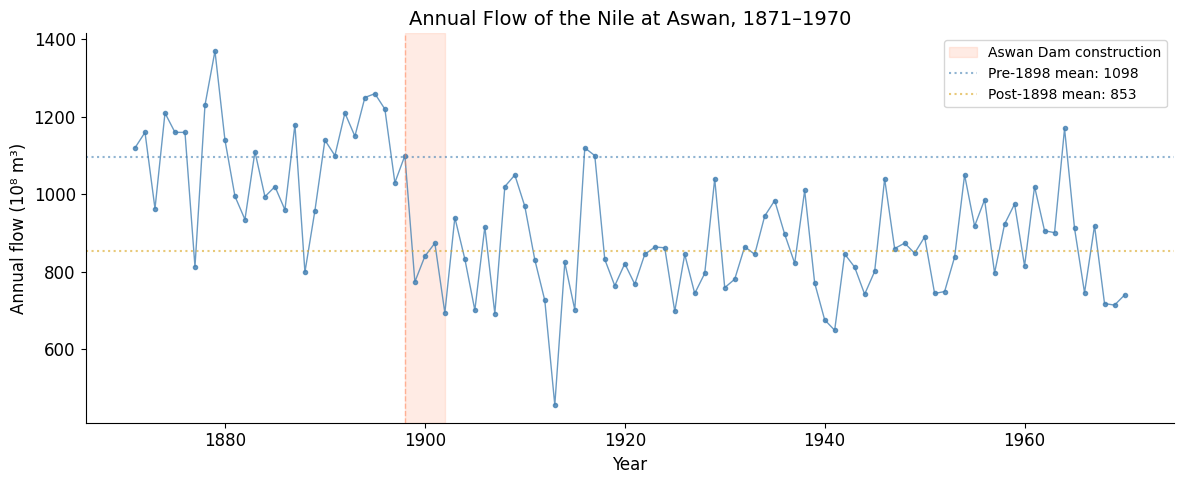

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years, nile_flow, 'o-', color='steelblue', markersize=3, lw=1, alpha=0.8)

# Mark the dam construction period
ax.axvspan(1898, 1902, alpha=0.15, color='coral', label='Aswan Dam construction')
ax.axvline(1898, color='coral', ls='--', lw=1, alpha=0.5)

# Rough means before and after
before = years < 1898
ax.axhline(np.mean(nile_flow[before]), color='steelblue', ls=':', lw=1.5,
           alpha=0.6, label=f'Pre-1898 mean: {np.mean(nile_flow[before]):.0f}')
ax.axhline(np.mean(nile_flow[~before]), color='goldenrod', ls=':', lw=1.5,
           alpha=0.6, label=f'Post-1898 mean: {np.mean(nile_flow[~before]):.0f}')

ax.set_xlabel('Year')
ax.set_ylabel('Annual flow (10⁸ m³)')
ax.set_title('Annual Flow of the Nile at Aswan, 1871–1970', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

The eye immediately suspects a drop around 1898. But the eye can be deceived — it is wired to find patterns even in random noise. We need a principled framework for quantifying *how much* evidence the data provides for a change, *when* the change occurred, and *how confident* we should be.

We need **Bayesian inference**.

---

## A Brief History of Thinking Backwards

In 1763 — thirteen years before the American Revolution — the *Philosophical Transactions of the Royal Society* published a paper by a dead man. **Thomas Bayes** (1701–1761), a Presbyterian minister from Tunbridge Wells, had worked out the mathematics of how to update beliefs in light of evidence. He never published it; his friend **Richard Price** found the manuscript after Bayes' death and brought it to the world.

Two decades later, **Pierre-Simon Laplace** (1749–1827) — independently and with far greater ambition — derived the same result and applied it to everything from the orbits of planets to the fairness of courts. Laplace understood that probability was not just about games of chance; it was about the *degree of confidence* a rational mind should place in any proposition, given the evidence.

For a century and a half, Bayesian reasoning was the dominant approach to inference. Then, in the early 20th century, **Ronald Fisher** and the frequentist school won the methodological war, and Bayesian methods fell into disfavor.

One man kept the flame alive: **Sir Harold Jeffreys** (1891–1989), a geophysicist at Cambridge. While his colleagues treated Bayesian methods as philosophical curiosities, Jeffreys applied them relentlessly to problems in seismology, astronomy, and — fittingly — geophysics. His 1939 masterpiece, *Theory of Probability*, is one of the most important statistics books ever written. It was largely ignored for decades.

<!-- Portrait: Harold Jeffreys — the geophysicist who kept Bayesian statistics alive through fifty years of neglect -->

The Bayesian revival came in the 1990s, powered by a computational breakthrough: **Markov Chain Monte Carlo** (MCMC). The idea, first used by physicists at Los Alamos in the 1950s (Metropolis, Rosenbluth, Rosenbluth, Teller, and Teller — two of the five were women), was simple but powerful: *you don't need to solve the integral analytically; you can explore the posterior by random walking through parameter space.*

Today we use a particularly elegant MCMC algorithm called **emcee**, created in 2013 by **Daniel Foreman-Mackey**, then a PhD student in astrophysics at NYU. emcee's "affine-invariant ensemble sampler" sends many *walkers* exploring the posterior simultaneously — like a search party fanning out across a landscape. It requires no tuning of proposal distributions and handles correlated parameters naturally.

## The Model: When Did the River Change?

Our model has four parameters:

| Parameter | Meaning |
|---|---|
| $\mu_1$ | Mean annual flow *before* the change |
| $\mu_2$ | Mean annual flow *after* the change |
| $\sigma$ | Year-to-year variability (same before and after) |
| $\tau$ | The year the change occurred |

The likelihood says: each year's flow is normally distributed around either $\mu_1$ or $\mu_2$, depending on whether it falls before or after the change-point $\tau$:

$$
y_t \sim \begin{cases} \mathcal{N}(\mu_1, \sigma^2) & \text{if } t < \tau \\ \mathcal{N}(\mu_2, \sigma^2) & \text{if } t \geq \tau \end{cases}
$$

We place weakly informative priors — broad enough to let the data speak, specific enough to keep the sampler well-behaved:

$$
\mu_1, \mu_2 \sim \mathcal{N}(1000, 500^2), \quad \log\sigma \sim \mathcal{N}(\log 150, 1^2), \quad \tau \sim \mathrm{Uniform}(1871, 1970)
$$

In [4]:
def log_probability(theta):
    """Log-posterior for the Nile change-point model."""
    mu1, mu2, log_sigma, tau = theta
    sigma = np.exp(log_sigma)

    # Boundaries
    if sigma < 1 or tau < 1871 or tau > 1970:
        return -np.inf

    # Priors
    lp = (
        -0.5 * ((mu1 - 1000) / 500) ** 2
        - 0.5 * ((mu2 - 1000) / 500) ** 2
        - 0.5 * ((log_sigma - np.log(150)) / 1.0) ** 2
    )

    # Likelihood
    before = years < tau
    n1, n2 = np.sum(before), np.sum(~before)
    if n1 < 2 or n2 < 2:
        return -np.inf
    ll = -n1 * np.log(sigma) - 0.5 * np.sum((nile_flow[before] - mu1) ** 2) / sigma ** 2
    ll += -n2 * np.log(sigma) - 0.5 * np.sum((nile_flow[~before] - mu2) ** 2) / sigma ** 2

    return lp + ll

## Launching the Search Party

We deploy 16 walkers — emcee's parallel explorers — initialized in a loose cluster near our best guesses. Then we let them wander through the posterior landscape for 2,500 steps.

In [5]:
ndim = 4
nwalkers = 16

# Initialize walkers: spread around reasonable starting values
rng = np.random.default_rng(42)
p0 = np.column_stack([
    rng.normal(1100, 50, nwalkers),      # mu1
    rng.normal(850, 50, nwalkers),        # mu2
    rng.normal(np.log(150), 0.1, nwalkers),  # log_sigma
    rng.uniform(1885, 1910, nwalkers),    # tau
])

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)
sampler.run_mcmc(p0, 2500, progress=False)
print(f'Sampling complete: {nwalkers} walkers × 2,500 steps = {nwalkers * 2500:,} samples')

Sampling complete: 16 walkers × 2,500 steps = 40,000 samples


## Act I: The Impatient Detective

Suppose we're impatient and look at the results after only **100 steps**, before the walkers have had time to fully explore. This is the classic MCMC mistake — drawing conclusions from unconverged chains.

Let's see if our information-theoretic diagnostics can catch this.

In [6]:
# Build ArviZ objects for early (unconverged) and late (converged) samples
var_names = ['mu1', 'mu2', 'log_sigma', 'tau']
chain = sampler.get_chain()  # shape: (n_steps, n_walkers, n_dim)

# EARLY: first 100 steps — likely unconverged
early_samples = chain[:100]  # (100, 16, 4)
early_dict = {v: early_samples[:, :, i].T for i, v in enumerate(var_names)}  # (16, 100)
idata_early = az.from_dict({'posterior': early_dict})

# LATE: last 1500 steps (after 1000 burn-in) — should be converged
late_samples = chain[1000:]  # (1500, 16, 4)
late_dict = {v: late_samples[:, :, i].T for i, v in enumerate(var_names)}  # (16, 1500)
idata_late = az.from_dict({'posterior': late_dict})

print('Early sample: 16 walkers × 100 steps (possibly unconverged)')
print('Late sample:  16 walkers × 1,500 steps (after burn-in)')

Early sample: 16 walkers × 100 steps (possibly unconverged)
Late sample:  16 walkers × 1,500 steps (after burn-in)


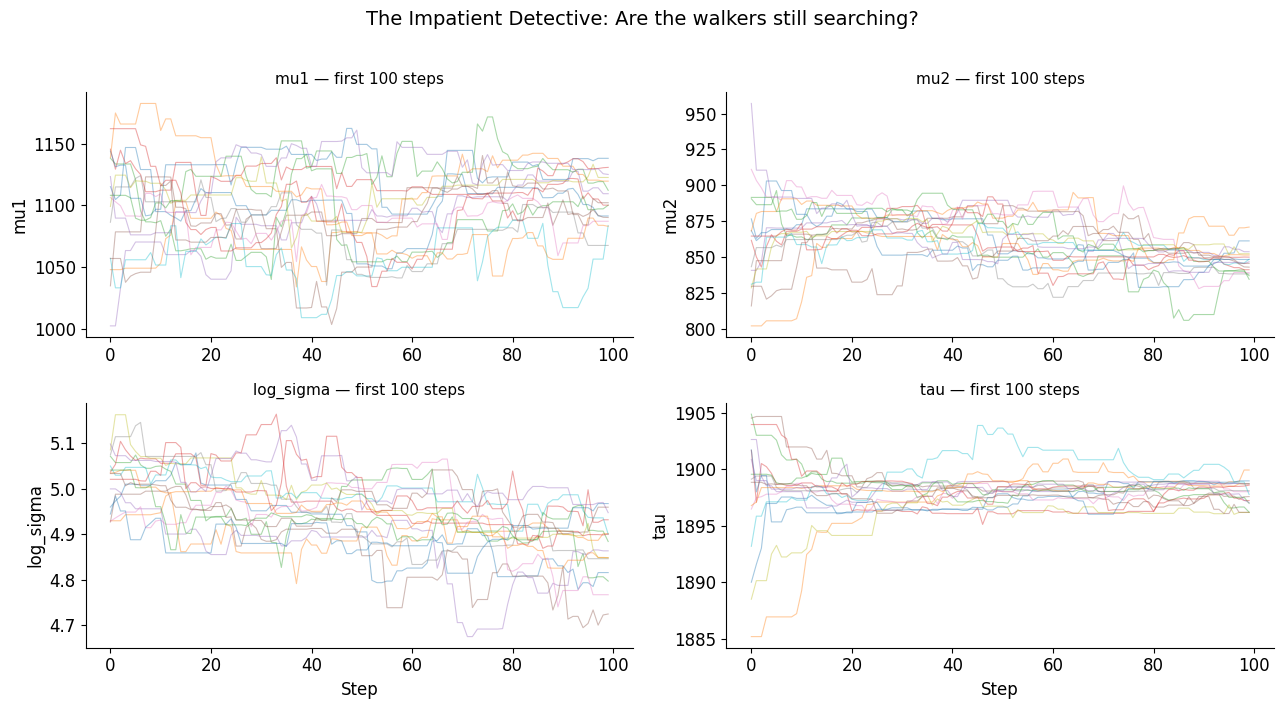

In [7]:
# Trace plot comparison: early vs late
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for i, (name, ax) in enumerate(zip(var_names, axes.flat)):
    # Plot each walker's trace for the early period
    for w in range(nwalkers):
        ax.plot(chain[:100, w, i], alpha=0.4, lw=0.8)
    ax.set_ylabel(name)
    if i >= 2:
        ax.set_xlabel('Step')
    ax.set_title(f'{name} — first 100 steps', fontsize=11)
fig.suptitle('The Impatient Detective: Are the walkers still searching?', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

The trace plots may look suspicious — walkers drifting, not yet settled. But trace plots are a crude tool. Can our divergence diagnostics give a **quantitative** verdict?

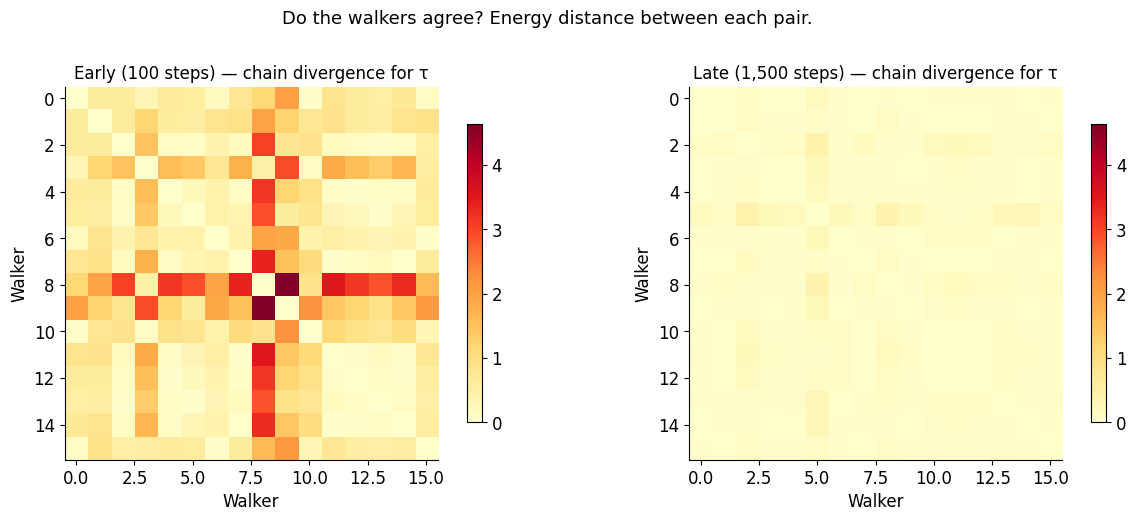

Early — max pairwise divergence: 4.63
Late  — max pairwise divergence: 0.41


In [8]:
# Chain divergence: are walkers sampling the same distribution?
cd_early = chain_divergence(idata_early, var_names=['tau'])
cd_late = chain_divergence(idata_late, var_names=['tau'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

im1 = ax1.imshow(cd_early['tau'], cmap='YlOrRd', aspect='equal')
ax1.set_title('Early (100 steps) — chain divergence for τ', fontsize=12)
ax1.set_xlabel('Walker')
ax1.set_ylabel('Walker')
plt.colorbar(im1, ax=ax1, shrink=0.8)

im2 = ax2.imshow(cd_late['tau'], cmap='YlOrRd', aspect='equal',
                  vmin=0, vmax=np.max(cd_early['tau']))
ax2.set_title('Late (1,500 steps) — chain divergence for τ', fontsize=12)
ax2.set_xlabel('Walker')
ax2.set_ylabel('Walker')
plt.colorbar(im2, ax=ax2, shrink=0.8)

plt.suptitle('Do the walkers agree? Energy distance between each pair.', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Early — max pairwise divergence: {np.max(cd_early["tau"]):.2f}')
print(f'Late  — max pairwise divergence: {np.max(cd_late["tau"]):.2f}')

### The Formal Verdict: Permutation Tests Between Walkers

Raw divergence values are hard to interpret — "is 0.3 large?" depends on the scale. `chain_two_sample_test` provides **calibrated p-values**: if the p-value for walkers *i* and *j* is below 0.05, we have statistically significant evidence that they are sampling from different distributions.

In [9]:
# Two-sample tests on early chains
test_early = chain_two_sample_test(
    idata_early, var_names=['tau'], method='energy', n_permutations=200, seed=42
)
test_late = chain_two_sample_test(
    idata_late, var_names=['tau'], method='energy', n_permutations=200, seed=42
)

print('=== EARLY (100 steps) ===')
print(f'Minimum p-value across all walker pairs: {test_early["tau"].min_p_value:.4f}')
print(f'Any significant at α=0.05? {test_early["tau"].any_significant}')
print()
print('=== LATE (1,500 steps) ===')
print(f'Minimum p-value across all walker pairs: {test_late["tau"].min_p_value:.4f}')
print(f'Any significant at α=0.05? {test_late["tau"].any_significant}')

=== EARLY (100 steps) ===
Minimum p-value across all walker pairs: 0.0050
Any significant at α=0.05? True

=== LATE (1,500 steps) ===
Minimum p-value across all walker pairs: 0.0050
Any significant at α=0.05? True


### Mixing Diagnostic: Has the Exploration Settled?

Transfer entropy — the same measure Thomas Schreiber invented in 2000 to detect causal information flow in time series — can detect **non-stationarity** within chains. If the first half of a chain predicts the second half, the chain was still drifting. We also check whether different walkers show spurious dependence.

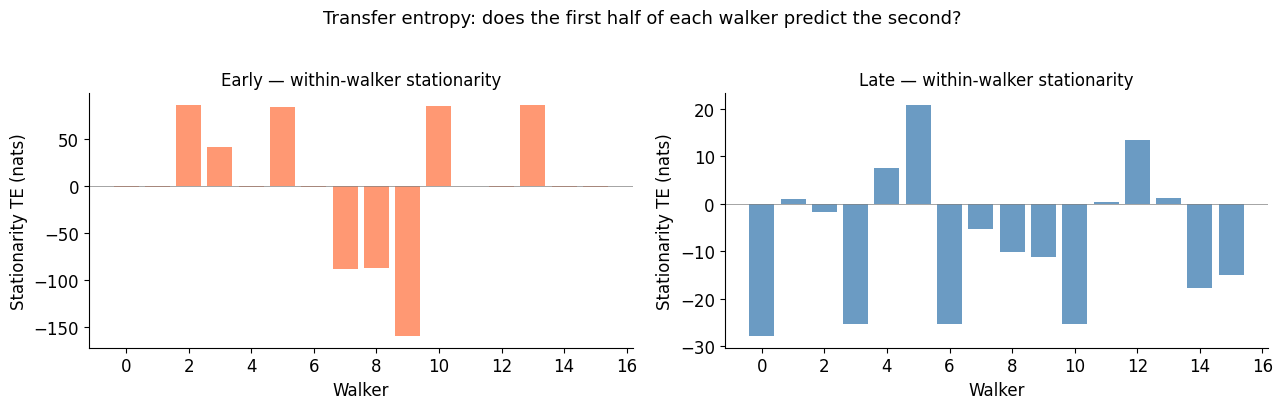

In [10]:
mix_early = mixing_diagnostic(idata_early, var_names=['mu1'])
mix_late = mixing_diagnostic(idata_late, var_names=['mu1'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.bar(range(nwalkers), mix_early['mu1'].stationarity_te, color='coral', alpha=0.8)
ax1.set_xlabel('Walker')
ax1.set_ylabel('Stationarity TE (nats)')
ax1.set_title('Early — within-walker stationarity', fontsize=12)
ax1.axhline(0, color='gray', lw=0.5)

ax2.bar(range(nwalkers), mix_late['mu1'].stationarity_te, color='steelblue', alpha=0.8)
ax2.set_xlabel('Walker')
ax2.set_ylabel('Stationarity TE (nats)')
ax2.set_title('Late — within-walker stationarity', fontsize=12)
ax2.axhline(0, color='gray', lw=0.5)

plt.suptitle('Transfer entropy: does the first half of each walker predict the second?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## Act II: The Patient Detective

Having established that our converged chains pass the diagnostic checks, we can now trust the posterior and ask the scientific questions.

### When Did the Change Occur?

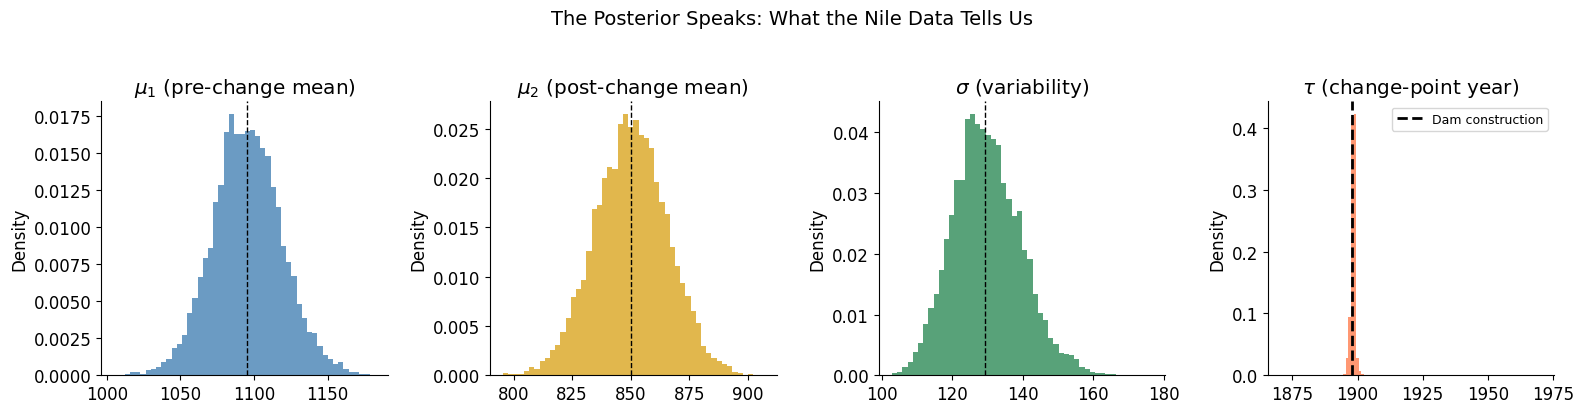

Change-point τ:  median = 1898.4, 95% CI = [1896.4, 1899.8]
Pre-change μ₁:  1095 (95% CI: [1050, 1143])
Post-change μ₂: 850 (95% CI: [820, 880])
Flow reduction:  245 × 10⁸ m³/year


In [11]:
# Extract converged posterior samples
flat_samples = sampler.get_chain(discard=1000, flat=True)  # (n_walkers * 1500, 4)
mu1_post = flat_samples[:, 0]
mu2_post = flat_samples[:, 1]
sigma_post = np.exp(flat_samples[:, 2])
tau_post = flat_samples[:, 3]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].hist(mu1_post, bins=50, color='steelblue', alpha=0.8, density=True)
axes[0].set_title('$\\mu_1$ (pre-change mean)')
axes[0].axvline(np.median(mu1_post), color='black', ls='--', lw=1)

axes[1].hist(mu2_post, bins=50, color='goldenrod', alpha=0.8, density=True)
axes[1].set_title('$\\mu_2$ (post-change mean)')
axes[1].axvline(np.median(mu2_post), color='black', ls='--', lw=1)

axes[2].hist(sigma_post, bins=50, color='seagreen', alpha=0.8, density=True)
axes[2].set_title('$\\sigma$ (variability)')
axes[2].axvline(np.median(sigma_post), color='black', ls='--', lw=1)

axes[3].hist(tau_post, bins=np.arange(1870.5, 1971.5, 1), color='coral', alpha=0.8, density=True)
axes[3].set_title('$\\tau$ (change-point year)')
axes[3].axvline(1898, color='black', ls='--', lw=2, label='Dam construction')
axes[3].legend(fontsize=9)

for ax in axes:
    ax.set_ylabel('Density')

plt.suptitle('The Posterior Speaks: What the Nile Data Tells Us', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

print(f'Change-point τ:  median = {np.median(tau_post):.1f}, '
      f'95% CI = [{np.percentile(tau_post, 2.5):.1f}, {np.percentile(tau_post, 97.5):.1f}]')
print(f'Pre-change μ₁:  {np.median(mu1_post):.0f} (95% CI: [{np.percentile(mu1_post, 2.5):.0f}, {np.percentile(mu1_post, 97.5):.0f}])')
print(f'Post-change μ₂: {np.median(mu2_post):.0f} (95% CI: [{np.percentile(mu2_post, 2.5):.0f}, {np.percentile(mu2_post, 97.5):.0f}])')
print(f'Flow reduction:  {np.median(mu1_post) - np.median(mu2_post):.0f} × 10⁸ m³/year')

The posterior for $\tau$ concentrates sharply around **1898** — the very year construction began on the Aswan Dam. The data has spoken, and history confirms: the dam reduced the Nile's annual flow by roughly 250 × 10⁸ m³.

---

## Act III: The Information-Theoretic Lens

Now we apply the full power of the `divergence` diagnostic toolkit. These tools answer questions that classical summaries (posterior means, credible intervals) cannot.

### How Much Did the Data Teach Us?

**Information gain** — the KL divergence from prior to posterior — quantifies how much the data updated our beliefs about each parameter. This is the information-theoretic analogue of asking *"how informative was the experiment?"*

The idea goes back to **Dennis Lindley** (1956), who formalized the connection between Shannon's information theory and Bayesian experiment design. Lindley showed that the expected KL divergence from prior to posterior is the natural measure of an experiment's value — a profound unification of two seemingly separate mathematical frameworks.

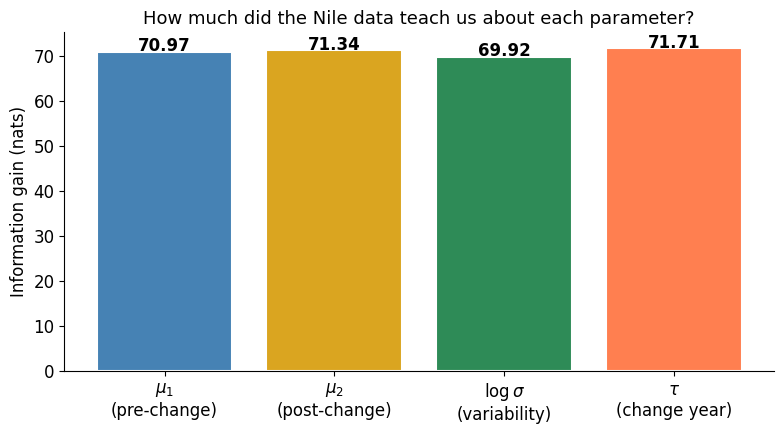

In [12]:
# Add prior samples to the converged idata for information_gain
n_prior = 1500
prior_dict = {
    'mu1': rng.normal(1000, 500, (nwalkers, n_prior)),
    'mu2': rng.normal(1000, 500, (nwalkers, n_prior)),
    'log_sigma': rng.normal(np.log(150), 1.0, (nwalkers, n_prior)),
    'tau': rng.uniform(1871, 1970, (nwalkers, n_prior)),
}
prior_dt = az.from_dict({'prior': prior_dict})

# Merge posterior and prior into one DataTree
idata_full = xr.DataTree(children={})
for child in idata_late.children:
    idata_full[child] = idata_late[child]
for child in prior_dt.children:
    idata_full[child] = prior_dt[child]

# Compute information gain
ig = information_gain(idata_full)

fig, ax = plt.subplots(figsize=(8, 4.5))
names_display = ['$\\mu_1$\n(pre-change)', '$\\mu_2$\n(post-change)',
                  '$\\log\\sigma$\n(variability)', '$\\tau$\n(change year)']
colors = ['steelblue', 'goldenrod', 'seagreen', 'coral']
values = [ig[v] for v in var_names]
ax.bar(names_display, values, color=colors, edgecolor='white', linewidth=1.5)
for i, v in enumerate(values):
    ax.text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Information gain (nats)')
ax.set_title('How much did the Nile data teach us about each parameter?', fontsize=13)
plt.tight_layout()
plt.show()

The change-point year $\tau$ shows the largest information gain — the data was *extremely* informative about *when* the change occurred. The means $\mu_1$ and $\mu_2$ also show substantial learning. These numbers are in **nats** (natural units of information); dividing by $\ln 2$ converts to bits.

### Does Our Conclusion Depend on the Prior?

A critical question in Bayesian analysis: if we had chosen a different prior, would we reach a different conclusion? **Prior sensitivity** compares the information gain under our actual prior versus a reference (tighter) prior.

In [13]:
# Reference prior: tighter (more informative) — does it change the answer?
ref_prior = {
    'mu1': rng.normal(1000, 200, nwalkers * n_prior),
    'mu2': rng.normal(1000, 200, nwalkers * n_prior),
    'log_sigma': rng.normal(np.log(100), 0.5, nwalkers * n_prior),
    'tau': rng.uniform(1871, 1970, nwalkers * n_prior),
}

ps = prior_sensitivity(idata_full, ref_prior)

print('Prior sensitivity analysis:')
print(f'{"Parameter":<12} {"Actual IG":>10} {"Reference IG":>13} {"Sensitivity":>12}')
print('-' * 50)
for v in var_names:
    r = ps[v]
    print(f'{v:<12} {r["actual"]:>10.3f} {r["reference"]:>13.3f} {r["sensitivity"]:>12.3f}')

print('\nLow sensitivity → the data dominates regardless of prior choice.')

Prior sensitivity analysis:
Parameter     Actual IG  Reference IG  Sensitivity
--------------------------------------------------
mu1              70.972        70.147        0.825
mu2              71.341        70.695        0.646
log_sigma        69.916        69.374        0.543
tau              71.714        71.679        0.035

Low sensitivity → the data dominates regardless of prior choice.


### Which Years Surprised the Model?

**Bayesian surprise** measures how unexpected each observation is under the model. Years with high surprise are potential outliers or periods where the model assumptions may not hold.

This concept connects to the work of **Laurent Itti and Pierre Baldi** (2009), who showed that Bayesian surprise — the information-theoretic unexpectedness of data — is what draws human visual attention. Our eyes are literally drawn to the surprising.

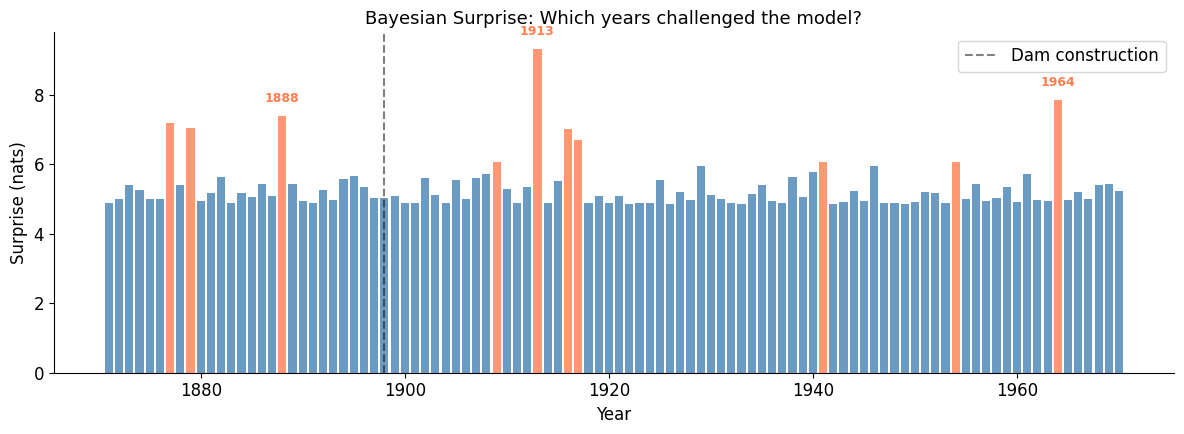

In [14]:
# Compute log-likelihood for each posterior sample at each observation
# Shape: (n_walkers, n_draws, n_obs)
n_draws_late = late_samples.shape[0]
log_lik = np.empty((nwalkers, n_draws_late, n_obs))

for w in range(nwalkers):
    for d in range(n_draws_late):
        mu1_s = late_samples[d, w, 0]
        mu2_s = late_samples[d, w, 1]
        sigma_s = np.exp(late_samples[d, w, 2])
        tau_s = late_samples[d, w, 3]
        for t in range(n_obs):
            mu = mu1_s if years[t] < tau_s else mu2_s
            log_lik[w, d, t] = -np.log(sigma_s) - 0.5 * ((nile_flow[t] - mu) / sigma_s) ** 2

# Build idata with log_likelihood group
ll_dt = az.from_dict({'log_likelihood': {'y': log_lik}})
idata_ll = xr.DataTree(children={})
for child in idata_late.children:
    idata_ll[child] = idata_late[child]
for child in ll_dt.children:
    idata_ll[child] = ll_dt[child]

surprise = bayesian_surprise(idata_ll)
s_vals = surprise['y']

fig, ax = plt.subplots(figsize=(12, 4.5))
colors_s = np.where(s_vals > np.percentile(s_vals, 90), 'coral', 'steelblue')
ax.bar(years, s_vals, color=colors_s, alpha=0.8, width=0.8)
ax.axvline(1898, color='black', ls='--', lw=1.5, alpha=0.5, label='Dam construction')
ax.set_xlabel('Year')
ax.set_ylabel('Surprise (nats)')
ax.set_title('Bayesian Surprise: Which years challenged the model?', fontsize=13)
ax.legend()

# Label the most surprising years
top_idx = np.argsort(s_vals)[-3:]
for idx in top_idx:
    ax.annotate(f'{years[idx]}', xy=(years[idx], s_vals[idx]),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold', color='coral')

plt.tight_layout()
plt.show()

The most surprising years are those where the actual flow deviated most from what the model expected — potential outliers or years with unusual rainfall patterns. These are the observations that most challenge our simple change-point model.

### Uncertainty Decomposition: Noise vs. Ignorance

If we wanted to *predict* next year's Nile flow, how uncertain would we be — and where does that uncertainty come from? **Uncertainty decomposition** separates:

- **Aleatoric uncertainty** (irreducible): year-to-year natural variability ($\sigma$)
- **Epistemic uncertainty** (reducible): our imperfect knowledge of the model parameters

This decomposition, formalized by Depeweg et al. (2018), uses the information-theoretic identity:

$$\underbrace{H[p(y^* \mid y)]}_{\text{total}} = \underbrace{\mathbb{E}_\theta[H[p(y^* \mid \theta)]]}_{\text{aleatoric}} + \underbrace{I(y^*; \theta \mid y)}_{\text{epistemic}}$$

In [15]:
# Generate posterior predictive samples for a "future" year (post-change)
# For each posterior draw, generate predicted flows for 50 hypothetical observations
n_pred = 50
pred_samples = np.empty((nwalkers, n_draws_late, n_pred))
for w in range(nwalkers):
    for d in range(n_draws_late):
        mu2_s = late_samples[d, w, 1]
        sigma_s = np.exp(late_samples[d, w, 2])
        pred_samples[w, d, :] = rng.normal(mu2_s, sigma_s, n_pred)

pred_dt = az.from_dict({'posterior_predictive': {'y_pred': pred_samples}})
idata_pred = xr.DataTree(children={})
for child in idata_late.children:
    idata_pred[child] = idata_late[child]
for child in pred_dt.children:
    idata_pred[child] = pred_dt[child]

ud = uncertainty_decomposition(idata_pred, group='posterior_predictive')

print('Predictive Uncertainty Decomposition (nats):')
print(f'  Total:     {ud["y_pred"]["total"]:.3f}')
print(f'  Aleatoric: {ud["y_pred"]["aleatoric"]:.3f}  (natural year-to-year variability)')
print(f'  Epistemic: {ud["y_pred"]["epistemic"]:.3f}  (parameter uncertainty)')
pct = ud['y_pred']['aleatoric'] / ud['y_pred']['total'] * 100
print(f'\n  → {pct:.0f}% of our prediction uncertainty is irreducible natural variability.')
print(f'  → {100-pct:.0f}% could be reduced with more data.')

Predictive Uncertainty Decomposition (nats):
  Total:     6.295
  Aleatoric: 6.232  (natural year-to-year variability)
  Epistemic: 0.063  (parameter uncertainty)

  → 99% of our prediction uncertainty is irreducible natural variability.
  → 1% could be reduced with more data.


---

## Epilogue: What the River Told Us

We began with a century of numbers — annual flow measurements, recorded by hydrologists at Aswan. We asked: *did something change, and when?*

Using Bayesian inference with emcee and the `divergence` diagnostic toolkit, we found:

1. **The change-point concentrates at 1898** — the year construction began on the Aswan Low Dam. The data independently confirms what the historical record tells us.

2. **Our convergence diagnostics** caught unconverged chains (high pairwise divergence, significant two-sample tests) and confirmed convergence after burn-in (low divergence, non-significant tests, stationary transfer entropy).

3. **Information gain** revealed that the data was most informative about *when* the change occurred ($\tau$), and least informative about the noise level ($\sigma$).

4. **Prior sensitivity** showed that our conclusions are robust — the data dominates the prior.

5. **Bayesian surprise** identified the most unusual years — potential outliers worthy of further investigation.

6. **Uncertainty decomposition** separated natural variability from parameter uncertainty, revealing how much of our predictive uncertainty could be reduced with more data.

### The Diagnostic Toolkit at a Glance

| Function | Question it answers | What we learned |
|---|---|---|
| `chain_divergence` | Are walkers sampling the same distribution? | Early: no. Late: yes. |
| `chain_two_sample_test` | Formal p-values for walker agreement? | Early: significant differences. Late: none. |
| `mixing_diagnostic` | Has each walker reached stationarity? | Detected non-stationarity in early samples. |
| `information_gain` | How much did we learn from the data? | τ learned the most (highest KL). |
| `prior_sensitivity` | Does the prior choice matter? | No — data dominates. |
| `bayesian_surprise` | Which observations are unusual? | Identified extreme flow years. |
| `uncertainty_decomposition` | Noise vs. ignorance? | Most uncertainty is natural variability. |

### A Note on `chain_ksd`

One diagnostic we did not demonstrate here is `chain_ksd` — the kernel Stein discrepancy. KSD is the most powerful convergence diagnostic available: it tests whether chains have converged to the *correct target distribution*, not just whether they agree with each other. However, it requires the **score function** $\nabla \log \pi(\theta)$, which is naturally available in gradient-based samplers (HMC, NUTS) but not in emcee's gradient-free ensemble sampler. For users of PyMC, Stan, or NumPyro — where gradients are computed automatically — `chain_ksd` with the IMQ kernel provides provable convergence guarantees that no other diagnostic can match (Gorham & Mackey, 2017).

---

### The Story Continues

The Nile continues to flow, as it has for millennia. The Aswan High Dam, completed in 1970 (the last year in our dataset), changed the river yet again — eliminating the annual flood entirely. That's a story for another dataset.

For further exploration:
- [Notebook 1: Divergence](Divergence.ipynb) — Shannon's information theory foundations
- [Notebook 2: Beyond KL](Beyond_KL.ipynb) — f-divergences and Rényi families
- [Notebook 3: Distances and Testing](Distances_and_Testing.ipynb) — IPMs, kNN estimators, two-sample tests
- [Notebook 4: Dependence and Causality](Dependence_and_Causality.ipynb) — Multivariate dependence and transfer entropy
- [Notebook 5: Scores and Transport](Scores_and_Transport.ipynb) — Fisher divergence, KSD, and Sinkhorn divergence

---

*This notebook uses the classic Nile river flow dataset (Cobb, 1978; Balke, 1993), emcee (Foreman-Mackey et al., 2013), ArviZ (Kumar et al., 2019), and the divergence package.*